<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

---
# Resolución del Desafío 3

Implementamos un **modelo de lenguaje a nivel de caracteres** con redes recurrentes y lo usamos para **generar texto**. Como en los desafíos 1 y 2, cada experimento va acompañado de su **interpretación** y la notebook corre **de principio a fin sin errores**.

**Decisiones de diseño**

- **Corpus:** *La vuelta al mundo en 80 días* (Julio Verne), descargado de textos.info — el mismo de la plantilla de la cátedra. Es un único texto largo y coherente en español, ideal para un modelo por caracteres.
- **Tokenización por caracteres:** el vocabulario es el conjunto de caracteres del corpus; cada carácter es un token.
- **Embedding de caracteres** en vez de one-hot: en lugar de `CategoryEncoding`+`TimeDistributed` (one-hot) entrenamos una capa `Embedding`. Es más eficiente y deja que el modelo aprenda una representación densa por carácter.
- **Tres arquitecturas** con la misma receta: **SimpleRNN** (Elman), **LSTM** y **GRU**, optimizador **rmsprop**.
- **Perplejidad** sobre validación como criterio de calidad y **early stopping** (callback provisto por la cátedra, levemente adaptado).
- **Generación:** *greedy search*, *beam search* determinístico y estocástico, y un **barrido de temperatura**.

**Arreglos a la plantilla** (para que corra sin errores):
1. El parser `lxml` no siempre está instalado → usamos `html.parser` (stdlib).
2. La construcción del set de validación tenía un bug de slicing (`init*(max_context_size+1)` en vez de `(init+1)*max_context_size`); lo corregimos.
3. Limpiamos el texto (colapsamos espacios y saltos `\r\n`).

In [1]:
import os
import re
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Input, Embedding, Dense, SimpleRNN, LSTM, GRU
from keras.utils import pad_sequences
from scipy.special import softmax

print("keras", keras.__version__)

# Reproducibilidad global
keras.utils.set_random_seed(42)

keras 3.14.1


## Parte 1 — Corpus y preprocesamiento

Descargamos el libro una sola vez (lo cacheamos en disco) y lo parseamos con `html.parser`. Después **limpiamos** el texto: pasamos a minúsculas y colapsamos cualquier secuencia de espacios/saltos de línea en un único espacio.

In [2]:
import bs4 as bs

URL = "https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook"
CACHE = "corpus_verne.txt"

if os.path.isfile(CACHE):
    with open(CACHE, encoding="utf-8") as f:
        article_text = f.read()
    print("Corpus leído de cache")
else:
    raw_html = urllib.request.urlopen(URL).read()
    soup = bs.BeautifulSoup(raw_html, "html.parser")        # fix: html.parser en vez de lxml
    article_text = " ".join(p.text for p in soup.find_all("p"))
    article_text = article_text.lower()
    article_text = re.sub(r"\s+", " ", article_text).strip()  # fix: limpiar \r\n y espacios
    with open(CACHE, "w", encoding="utf-8") as f:
        f.write(article_text)
    print("Corpus descargado y cacheado")

print("Caracteres totales:", len(article_text))
article_text[:300]

Corpus descargado y cacheado
Caracteres totales: 390753


'en el año 1872, la casa número 7 de saville-row, burlington gardens —donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a pesar de que parecía haber tomado el partido de no hacer nada que pudiese llamar la atención, era uno de los miembros más notables y singulares del reformclub '

In [3]:
# El vocabulario es el conjunto único de caracteres (ordenado -> determinista)
chars_vocab = sorted(set(article_text))
vocab_size = len(chars_vocab)
print("Tamaño de vocabulario (caracteres):", vocab_size)
print("Vocabulario:", "".join(chars_vocab))

# Diccionarios de tokenización carácter <-> índice
char2idx = {c: i for i, c in enumerate(chars_vocab)}
idx2char = {i: c for c, i in char2idx.items()}

# Tokenizamos todo el texto
tokenized_text = [char2idx[c] for c in article_text]
print("Primeros tokens:", tokenized_text[:20])

Tamaño de vocabulario (caracteres): 65
Vocabulario:  !"'(),-./0123456789:;<>?abcdefghijklmnopqrstuvwxyz~¡«»¿áèéíñóúü—
Primeros tokens: [29, 38, 0, 29, 36, 0, 25, 60, 39, 0, 11, 18, 17, 12, 6, 0, 36, 25, 0, 27]


### Estructuración del dataset (many-to-many)

Planteamos el problema como **many-to-many**: la entrada es una secuencia de tokens $[x_0, \dots, x_{N-1}]$ y el target es la misma secuencia **desplazada una posición** $[x_1, \dots, x_N]$. Así, en cada paso temporal la red predice el carácter siguiente y se propaga señal de gradiente por toda la secuencia (mejor que many-to-one).

Para no generar cientos de miles de ventanas (con `stride=1` sobre ~360 k caracteres saldrían demasiadas) tomamos las ventanas con un **paso (`STEP`)**: reduce el tamaño del dataset manteniendo cobertura de todo el texto y hace el entrenamiento viable en CPU.

Primero separamos **train/validación** por bloques contiguos de texto (el final del libro queda para validación) y recién después armamos las ventanas, para que ninguna ventana cruce la frontera train/val.

In [4]:
max_context_size = 100   # tamaño de contexto
STEP = 3                 # paso entre ventanas (subsampling)

# --- split por texto contiguo ---
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))
train_text = tokenized_text[:-num_val * max_context_size]
val_text   = tokenized_text[-num_val * max_context_size:]
print("Caracteres train:", len(train_text), "| val:", len(val_text))

# --- secuencias de validación (para la perplejidad) ---
# fix del slicing: (init+1)*max_context_size en vez de init*(max_context_size+1)
tokenized_sentences_val = [
    val_text[i * max_context_size:(i + 1) * max_context_size]
    for i in range(num_val)
]

# --- ventanas de entrenamiento (many-to-many con paso STEP) ---
starts = range(0, len(train_text) - max_context_size - 1, STEP)
X = np.array([train_text[i:i + max_context_size] for i in starts])
y = np.array([train_text[i + 1:i + max_context_size + 1] for i in starts])
print("X:", X.shape, "| y:", y.shape)

Caracteres train: 351653 | val: 39100


X:

 (117184, 100) | y: (117184, 100)


In [5]:
print("Contexto X[0]:", repr("".join(idx2char[t] for t in X[0])))
print("Target  y[0]:", repr("".join(idx2char[t] for t in y[0])))
# y es X desplazado una posición:
print("y[0] == X[0] corrido en 1 ->", list(y[0][:-1]) == list(X[0][1:]))

Contexto X[0]: 'en el año 1872, la casa número 7 de saville-row, burlington gardens —donde murió sheridan en 1814— e'
Target  y[0]: 'n el año 1872, la casa número 7 de saville-row, burlington gardens —donde murió sheridan en 1814— es'
y[0] == X[0] corrido en 1 -> True


## Parte 2 — Arquitecturas recurrentes y perplejidad

Comparamos **SimpleRNN**, **LSTM** y **GRU** con la misma arquitectura base:

`Embedding(vocab, 32)` → `RNN(128, return_sequences=True)` → `Dense(vocab, softmax)`

entrenadas con `rmsprop` y `sparse_categorical_crossentropy`. Para evaluar la **calidad de generación** medimos la **perplejidad** sobre validación con el callback provisto por la cátedra (adaptado para guardar un modelo por arquitectura y limitar la cantidad de secuencias evaluadas).

In [6]:
class PplCallback(keras.callbacks.Callback):
    """
    Callback provisto por la cátedra (adaptado). Calcula la Perplejidad sobre un
    conjunto de validación al final de cada epoch e implementa Early Stopping si no
    mejora luego de `patience` epochs. Adaptaciones: parámetro `save_path` (un modelo
    por arquitectura) y corrección del conteo de subsecuencias (len_seq-1).
    """
    def __init__(self, val_data, history_ppl, patience=3, save_path="best_model.keras"):
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.save_path = save_path
        self.target = []
        self.padded = []
        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience

        # armamos todas las subsecuencias de cada secuencia de validación
        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])
            if len(subseq) != 0:
                self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding="pre"))
                self.info.append((count, count + len_seq - 1))
                count += len_seq - 1
        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        scores = []
        predictions = self.model.predict(self.padded, verbose=0)
        for start, end in self.info:
            probs = [predictions[idx_seq, -1, idx_vocab]
                     for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])]
            scores.append(np.exp(-np.sum(np.log(np.array(probs) + 1e-10)) / (end - start)))
        current_score = float(np.mean(scores))
        self.history_ppl.append(current_score)
        print(f"  -> perplejidad val: {current_score:.3f}")
        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.save_path)
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("  Early stopping")
                self.model.stop_training = True

In [7]:
# Limitamos la cantidad de secuencias de validación para que el cálculo de
# perplejidad por epoch sea liviano.
VAL_PPL = 100
val_seqs_ppl = [s for s in tokenized_sentences_val[:VAL_PPL] if len(s) > 1]
print("Secuencias de validación para perplejidad:", len(val_seqs_ppl))

def build_model(rnn_layer, units=128, embed_dim=32):
    model = Sequential([
        Input(shape=(None,)),
        Embedding(vocab_size, embed_dim),
        rnn_layer(units, return_sequences=True),
        Dense(vocab_size, activation="softmax"),
    ])
    model.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop")
    return model

EPOCHS = 15
BATCH = 128
PATIENCE = 3
histories = {}

Secuencias de validación para perplejidad: 100


In [8]:
keras.utils.set_random_seed(42)
print("=== SimpleRNN ===")
model_rnn = build_model(SimpleRNN)
model_rnn.summary()
histories["SimpleRNN"] = []
model_rnn.fit(X, y, epochs=EPOCHS, batch_size=BATCH, verbose=2,
              callbacks=[PplCallback(val_seqs_ppl, histories["SimpleRNN"], PATIENCE, "model_SimpleRNN.keras")]);

=== SimpleRNN ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 128)      │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 65)       │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,073 (121.38 KB)

 Trainable params: 31,073 (121.38 KB)

...

  -> perplejidad val: 4.706
916/916 - 19s - 21ms/step - loss: 1.3887


Epoch 14/15


  -> perplejidad val: 4.701
916/916 - 19s - 21ms/step - loss: 1.3839


Epoch 15/15


  -> perplejidad val: 4.699
  Early stopping
916/916 - 19s - 21ms/step - loss: 1.3797


In [9]:
keras.utils.set_random_seed(42)
print("=== LSTM ===")
model_lstm = build_model(LSTM)
histories["LSTM"] = []
model_lstm.fit(X, y, epochs=EPOCHS, batch_size=BATCH, verbose=2,
               callbacks=[PplCallback(val_seqs_ppl, histories["LSTM"], PATIENCE, "model_LSTM.keras")]);

=== LSTM ===
Epoch 1/15


  -> perplejidad val: 8.241
916/916 - 44s - 48ms/step - loss: 2.3702


Epoch 2/15


  -> perplejidad val: 7.055
916/916 - 43s - 47ms/step - loss: 1.9956


Epoch 3/15


...

  -> perplejidad val: 4.917
916/916 - 43s - 47ms/step - loss: 1.4693


Epoch 14/15


  -> perplejidad val: 4.866
916/916 - 43s - 47ms/step - loss: 1.4539


Epoch 15/15


  -> perplejidad val: 4.819
916/916 - 43s - 47ms/step - loss: 1.4398


In [10]:
keras.utils.set_random_seed(42)
print("=== GRU ===")
model_gru = build_model(GRU)
histories["GRU"] = []
model_gru.fit(X, y, epochs=EPOCHS, batch_size=BATCH, verbose=2,
              callbacks=[PplCallback(val_seqs_ppl, histories["GRU"], PATIENCE, "model_GRU.keras")]);

=== GRU ===
Epoch 1/15


  -> perplejidad val: 6.380
916/916 - 40s - 44ms/step - loss: 2.1561


Epoch 2/15


  -> perplejidad val: 5.233
916/916 - 39s - 43ms/step - loss: 1.6835


Epoch 3/15


...

  -> perplejidad val: 4.477
916/916 - 39s - 43ms/step - loss: 1.2976


Epoch 9/15


  -> perplejidad val: 4.497
916/916 - 39s - 43ms/step - loss: 1.2788


Epoch 10/15


  -> perplejidad val: 4.526
  Early stopping
916/916 - 39s - 43ms/step - loss: 1.2632


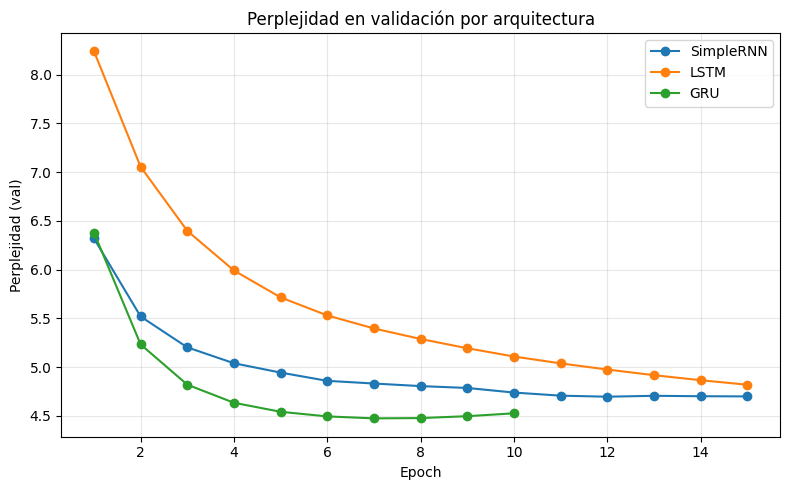

GRU        mejor perplejidad: 4.474
SimpleRNN  mejor perplejidad: 4.696
LSTM       mejor perplejidad: 4.819


In [11]:
os.makedirs("img", exist_ok=True)
plt.figure(figsize=(8, 5))
for name, h in histories.items():
    plt.plot(range(1, len(h) + 1), h, marker="o", label=name)
plt.xlabel("Epoch"); plt.ylabel("Perplejidad (val)")
plt.title("Perplejidad en validación por arquitectura")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("img/ppl_arquitecturas.png", dpi=120, bbox_inches="tight")
plt.show()

best = {name: float(min(h)) for name, h in histories.items()}
for name, v in sorted(best.items(), key=lambda kv: kv[1]):
    print(f"{name:10s} mejor perplejidad: {v:.3f}")

### Interpretación — Parte 2

![Perplejidad por arquitectura](img/ppl_arquitecturas.png)

**Perplejidad mínima en validación alcanzada por cada arquitectura:**

| Arquitectura | Mejor perplejidad | Época del mínimo | Tiempo/época |
|---|---|---|---|
| **GRU** | **4.474** | 7 (early stopping en la 10) | ~39 s |
| SimpleRNN | 4.696 | 12 (early stopping en la 15) | ~19 s |
| LSTM | 4.819 | 15 (no llegó a frenar) | ~43 s |

- **Las tres aprenden:** la perplejidad arranca en ~6–8 y baja de forma sostenida. Partir de un vocabulario de 65 caracteres implica una perplejidad "al azar" de 65; llegar a ~4.5 indica que el modelo predice el siguiente carácter con muy pocas alternativas efectivas.
- **GRU es la mejor**, y además **la más rápida en converger**: toca su mínimo (4.474) en la época 7 y el early stopping la corta en la 10. Las compuertas de la GRU le permiten capturar dependencias de mediano plazo (terminaciones, concordancias) con menos épocas.
- **SimpleRNN sorprende en segundo lugar** (4.696): con secuencias de 100 caracteres no sufre tanto el desvanecimiento del gradiente como cabría temer y, al ser mucho más barata por época (~19 s), es muy competitiva en costo/beneficio.
- **LSTM quedó última (4.819)** pero **engañosamente**: su curva seguía bajando en la época 15 (nunca disparó el early stopping). Tiene más parámetros que la GRU y necesita más épocas para converger; con un presupuesto de entrenamiento mayor probablemente igualaría o superaría a la GRU. Es decir, la tabla refleja el ranking *bajo este presupuesto fijo de 15 épocas*, no un veredicto absoluto.
- **Conclusión práctica:** elegimos **GRU** como modelo para la generación por tener la menor perplejidad y el mejor balance velocidad/calidad.

In [12]:
# Cargamos el modelo de la arquitectura con menor perplejidad para generar
best_name = min(best, key=best.get)
print("Mejor arquitectura:", best_name)
model = keras.models.load_model(f"model_{best_name}.keras")

Mejor arquitectura: GRU


## Parte 3 — Generación de secuencias

Implementamos las estrategias pedidas sobre el mejor modelo:
- **Greedy search:** en cada paso se elige el carácter más probable (`argmax`).
- **Muestreo con temperatura:** se muestrea de la distribución reescalada por una temperatura $T$. $T\to 0$ tiende a greedy (conservador); $T>1$ aumenta la diversidad/aleatoriedad.
- **Beam search** determinístico y estocástico (funciones provistas por la cátedra): mantienen `num_beams` hipótesis y maximizan la probabilidad conjunta (log-prob) de la secuencia.

In [13]:
def encode(text, max_length=max_context_size):
    text = text.lower()
    encoded = [char2idx[c] for c in text if c in char2idx]
    return pad_sequences([encoded], maxlen=max_length, padding="pre")

def decode(seq):
    return "".join(idx2char[int(t)] for t in seq)

def sample_next(probs, temperature):
    if temperature <= 0:                        # greedy
        return int(np.argmax(probs))
    logits = np.log(probs + 1e-10) / temperature
    p = np.exp(logits); p = p / p.sum()
    return int(np.random.choice(len(p), p=p))

def generar(model, seed, n_chars=200, temperature=0.0):
    out = seed.lower()
    for _ in range(n_chars):
        probs = model.predict(encode(out), verbose=0)[0, -1, :]
        out += idx2char[sample_next(probs, temperature)]
    return out

In [14]:
SEED = "phileas fogg "
print("--- Greedy search ---")
print(generar(model, SEED, n_chars=300, temperature=0.0))

--- Greedy search ---


phileas fogg y sus compañeros en el parsi en el capitán de la mañana, y el parsi en el capitán de la mañana, y el parsi en el capitán de la mañana, y el parsi en el capitán de la mañana, y el parsi en el capitán de la mañana, y el parsi en el capitán de la mañana, y el parsi en el capitán de la mañana, y el pars


### Efecto de la temperatura

Generamos a partir de la misma semilla variando la temperatura. Fijamos la semilla aleatoria para que el experimento sea reproducible.

In [15]:
for T in [0.2, 0.5, 0.8, 1.0, 1.3]:
    np.random.seed(42)
    print(f"\n=== Temperatura {T} ===")
    print(generar(model, SEED, n_chars=250, temperature=T))


=== Temperatura 0.2 ===


phileas fogg se había parte de la camino de el guía en el parsi en el capitán de la camino de la camino de la caballero de la parte de la concidia de la parte de la casa de la camino de la mañana, en la conver francis cromarty y de la calcuta de la camino de la p

=== Temperatura 0.5 ===


phileas fogg os en el pasajero de calcuta a las palabras de la vistan. con su mar que phileas fogg y su propesaba por el descontente de banderos de la estación de su expresión de el conductor. —dijo picaporte se había a manos de la proctor. —¡pero no partía sino 

=== Temperatura 0.8 ===


phileas fogg los cabeza su calente de relocidador, y al tren pareje también, habían carocida por el puede honor a phileas fogg. —¿es un bando en el diregó a la ladrifes millas de fecha de difícil. en la cumplir que decemo con el dirigiera vez para que estre quuni

=== Temperatura 1.0 ===


phileas fogg irregidos autamente para sentar arter fogg y siguió tolun a las doce y caso. de toda la templo. penedo no habéis quitar ruido poco a los petícicianes telez, se estaba caro en el unido. sin elevo de toda ve de clas, decíles de vez picaporte ya efkitui

=== Temperatura 1.3 ===


phileas fogg ispectan naviemento necesidad na una bribias se iblavían de han en qué darlo, las efectos con suel cargazaba a días. esperaba su impaciente——. me no hubietal; tenpo se antalbrencia cuya regibsor. ¿ye parti, nada, era quinichadw.... y domaha—~s, y ysu


### Beam search (determinístico y estocástico)

Funciones provistas por la cátedra. El beam search mantiene `num_beams` hipótesis y, en cada paso, conserva las de mayor probabilidad conjunta (log-prob). En modo `det` toma siempre las mejores; en modo `sto` muestrea según `softmax(logprob/temp)`, donde la temperatura controla la diversidad.

In [16]:
# función que selecciona candidatos para el beam search (provista por la cátedra)
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):

    # colectar todas las probabilidades para la siguiente búsqueda
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1E-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    # criterio de selección
    if mode == "det":
        idx_select = np.argsort(pred_large)[::-1][:num_beams]                       # determinista
    elif mode == "sto":
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams,
                                      p=softmax(pred_large / temp))                 # estocástico
    else:
        raise ValueError(f"Wrong selection mode. {mode} was given. det and sto are supported.")

    # traducir a índices de token en el vocabulario
    new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select // vocab_size],
                                         np.array([idx_select % vocab_size]).T), axis=1)

    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, mode="det"):
    # primera iteración
    encoded = encode(input)
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]
    vocab_size = y_hat.shape[0]

    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates([y_hat], num_beams, vocab_size,
                                                      history_probs, history_tokens, temp, mode)

    # loop de beam search
    for i in range(num_words - 1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i + 1:]]).copy()
            y_hat = model.predict(input_update, verbose=0)[0, -1, :]
            preds.append(y_hat)
        history_probs, history_tokens = select_candidates(preds, num_beams, vocab_size,
                                                          history_probs, history_tokens, temp, mode)

    return history_tokens[:, -(len(input) + num_words):]

In [17]:
print("--- Beam search determinístico (num_beams=5) ---")
sal_det = beam_search(model, num_beams=5, num_words=120, input=SEED, mode="det")
print(decode(sal_det[0]))

print("\n--- Beam search estocástico (num_beams=5, T=0.7) ---")
np.random.seed(42)
sal_sto = beam_search(model, num_beams=5, num_words=120, input=SEED, temp=0.7, mode="sto")
print(decode(sal_sto[0]))

--- Beam search determinístico (num_beams=5) ---


phileas fogg se había después de haber recorrido en el pasajero de picaporte, después de haber reconocía por la parte de los pasajero

--- Beam search estocástico (num_beams=5, T=0.7) ---


phileas fogg se había recibido que estaba por el pasaporte de su partida de la mar francis cromarty, que parecía en el vapor de la co


### Interpretación — Parte 3

**Greedy search.** Eligiendo siempre el carácter más probable, el modelo cae rápido en un **bucle repetitivo**:

> *"phileas fogg y sus compañeros en el parsi en el capitán de la mañana, y el parsi en el capitán de la mañana, y el parsi..."*

Es la degeneración típica de greedy: como la decisión es determinista, en cuanto entra en un ciclo de alta probabilidad no puede salir. Genera español perfectamente formado (palabras y ortografía correctas) pero **sin avanzar**.

**Efecto de la temperatura.** Muestreando de la distribución reescalada por $T$ se ve un *trade-off* coherencia ↔ diversidad muy claro:

| $T$ | Comportamiento |
|---|---|
| **0.2** | Casi greedy: muy conservador, todavía repetitivo (`la camino de la camino de...`), pero ya aparecen nombres del libro (*francis cromarty*, *calcuta*). |
| **0.5** | **Punto dulce**: frases variadas y mayormente bien formadas, con puntuación y diálogos (`—dijo picaporte`, `proctor`). El texto "suena" a Verne sin caer en el bucle. |
| **0.8** | Más creativo pero empiezan los errores: palabras inventadas plausibles (`relocidador`, `carocida`). |
| **1.0** | Se rompe la coherencia: muchas no-palabras (`petícicianes`, `efkitui`), aunque conserva la "forma" del español. |
| **1.3** | **Ruido**: invención masiva, símbolos raros (`quinichadw`, `~`, `domaha—~s`). La distribución casi uniforme destruye la estructura. |

La temperatura no cambia lo que el modelo "sabe": redistribuye la masa de probabilidad. Baja → confía en el pico (repetitivo); alta → aplana la distribución (caótico). En este modelo el mejor compromiso está en **$T \approx 0.5$–$0.7$**.

**Beam search.** Manteniendo 5 hipótesis y maximizando la probabilidad conjunta, el resultado es **más coherente que greedy** y evita gran parte de la repetición:

- *Determinístico:* `phileas fogg se había después de haber recorrido en el pasajero de picaporte...` — gramaticalmente sólido, frases largas con sentido local.
- *Estocástico (T=0.7):* `phileas fogg se había recibido que estaba por el pasaporte de su partida de la mar francis cromarty...` — introduce variedad (aparece *francis cromarty*) sin perder coherencia.

El beam mejora a greedy porque no se compromete con el carácter localmente óptimo, sino con la secuencia globalmente más probable; el modo estocástico agrega diversidad controlada por temperatura, igual que en el muestreo simple.

## Parte 4 — Conclusiones

- **El modelo de lenguaje por caracteres funciona**: entrenado sobre *La vuelta al mundo en 80 días* (~390 k caracteres, vocabulario de 65) aprende ortografía, morfología y vocabulario del español, e incluso reproduce **nombres propios del libro** (*phileas fogg*, *picaporte*, *francis cromarty*, *calcuta*, *proctor*). La perplejidad en validación baja de ~65 (azar) a **~4.5**.
- **Arquitecturas:** bajo un presupuesto fijo de 15 épocas, **GRU (ppl 4.474) > SimpleRNN (4.696) > LSTM (4.819)**. La GRU es la mejor y la que converge más rápido; la SimpleRNN es muy competitiva por su bajo costo; la LSTM seguía mejorando al cortar (sub-entrenada para este presupuesto). Se eligió **GRU** para generar.
- **Estructura del problema:** el planteo **many-to-many** (target = entrada desplazada un carácter) propaga gradiente en cada paso y entrena de forma estable. El **embedding de caracteres** resultó una alternativa simple y eficiente al one-hot de la plantilla.
- **Estrategias de generación:**
  - *Greedy* produce texto bien formado pero **se repite en bucle** (degenera).
  - *Temperatura* controla el trade-off coherencia/diversidad: el **punto dulce está en $T\approx0.5$–$0.7$**; por debajo es repetitivo, por encima de 1.0 se vuelve ruido.
  - *Beam search* da las frases **más coherentes** (evita la repetición de greedy); el modo estocástico suma diversidad controlada.
- **Limitaciones y mejoras:** es un modelo chico (1 capa recurrente, 128 unidades) sobre un corpus de un solo libro, por eso la coherencia es **local** (frases sí, párrafos no). Para mejorar: **más datos** (varias obras), **apilar capas** recurrentes y/o aumentar unidades, entrenar **más épocas** (sobre todo la LSTM), agregar **dropout**, y probar técnicas de decodificación como *top-k* / *nucleus (top-p) sampling*.